
# Take new Dataset and perform the Encoding Techniques

# Scaling + OneHot Encoding Workflow

## Why MinMaxScaler?

Before choosing a scaling technique, check for outliers using a **Box Plot**.

```python
sns.boxplot(data=X[num_cols])
```

### Selection Rule

- **Few or No Outliers → MinMaxScaler**
- **Many Outliers → RobustScaler**
- **Normally Distributed Data → StandardScaler**

Since the dataset contains **very few outliers**, **MinMaxScaler** is the best choice.

It scales numerical values between **0 and 1**.

---

## Step 1 : Separate Features and Target

```python
X = df.drop(columns="Exam_Score")
y = df["Exam_Score"]
```

---

## Step 2 : Separate Numerical and Categorical Columns

```python
num_cols = X.select_dtypes(include="number").columns
obj_cols = X.select_dtypes(include="object").columns
```

- Numerical columns → Scaling
- Categorical columns → Encoding

---

## Step 3 : Train-Test Split

```python
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    train_size=0.8,
    random_state=42
)
```

> **Always split the dataset before preprocessing** to prevent **Data Leakage**.

---

## Step 4 : Scale Numerical Columns

```python
scaler = MinMaxScaler()

X_train[num_cols] = scaler.fit_transform(X_train[num_cols])

X_test[num_cols] = scaler.transform(X_test[num_cols])
```

### Why?

- `fit()` learns **Minimum** and **Maximum** values.
- `transform()` scales using the learned values.
- Use **fit_transform()** only on training data.
- Use **transform()** only on testing data.

---

## Step 5 : Encode Categorical Columns

```python
encoder = OneHotEncoder(
    sparse_output=False,
    handle_unknown="ignore"
)
```

### Why OneHotEncoder?

- Dataset has multiple categorical columns.
- Categories have **no natural order**.
- Creates binary (0/1) columns without introducing false ordering.

Example

```
Gender

Male
Female

↓

Gender_Male
Gender_Female

1 0
0 1
```

### Parameters

- `sparse_output=False` → Returns a NumPy array.
- `handle_unknown="ignore"` → Unknown categories are encoded as all zeros instead of raising an error.

---

## Step 6 : Fit Encoder

```python
encoded_train = encoder.fit_transform(X_train[obj_cols])
```

During **fit()**, OneHotEncoder:

- Finds unique values.
- Sorts them alphabetically.
- Creates binary columns.
- Stores the mapping.

---

## Step 7 : Transform Test Data

```python
encoded_test = encoder.transform(X_test[obj_cols])
```

Use only **transform()** because the encoder has already learned the categories.

---

## Step 8 : Get New Column Names

```python
cols = encoder.get_feature_names_out(obj_cols)
```

Example

```
Gender_Female
Gender_Male
School_Private
School_Public
```

---

## Step 9 : Convert to DataFrame

```python
encoded_train = pd.DataFrame(
    encoded_train,
    columns=cols,
    index=X_train.index
)
```

Keeping the same index prevents row mismatch during concatenation.

---

## Step 10 : Drop Original Columns

```python
X_train.drop(columns=obj_cols, inplace=True)
```

Remove original categorical columns after encoding.

---

## Step 11 : Add Encoded Columns

```python
X_train = pd.concat([X_train, encoded_train], axis=1)
```

Now all feature columns are numerical.

---

## Step 12 : Train the Model

```python
model = LinearRegression()

model.fit(X_train, y_train)
```

---

## Step 13 : Evaluate the Model

```python
train_score = model.score(X_train, y_train)

test_score = model.score(X_test, y_test)
```

### Model Interpretation

| Train Score | Test Score | Conclusion |
|-------------|------------|------------|
| Nearly Equal | Nearly Equal | ✅ Good Fit |
| High | Low | ⚠️ Overfitting |
| Low | Low | ❌ Underfitting |

---

# Important Interview Points

- Perform **Train-Test Split before preprocessing**.
- Scale **only numerical columns**.
- Encode **only categorical columns**.
- Fit scaler/encoder only on **training data**.
- Apply only **transform()** on testing data.
- MinMaxScaler scales values between **0 and 1**.
- OneHotEncoder is suitable for **categorical features without order**.
- Use `handle_unknown="ignore"` to avoid errors from unseen categories.
- Remove original categorical columns after encoding.
- The final dataset should contain **only numerical features** before training.

---



```

In [6]:
import pandas as pd

df = pd.read_csv('StudentPerformanceFactors.csv')
df.head()

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male,67
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female,61
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,Medium,Medium,Public,Negative,4,No,High School,Moderate,Male,71
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,Medium,High,Public,Neutral,4,No,College,Near,Female,70


In [7]:
# ============================================================
# STEP 1 : Import Required Libraries
# ============================================================

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import OneHotEncoder

from sklearn.linear_model import LinearRegression

# ============================================================
# STEP 2 : Separate Features and Target
# ============================================================

X = df.drop(columns="Exam_Score")
y = df["Exam_Score"]

# ============================================================
# STEP 3 : Check Numerical and Object Columns
# ============================================================

num_cols = X.select_dtypes(include="number").columns

obj_cols = X.select_dtypes(include="object").columns  ## it is a dataframe so include the columns to avoid error 

print("Numerical Columns")
print(num_cols)

print()

print("Categorical Columns")
print(obj_cols)


Numerical Columns
Index(['Hours_Studied', 'Attendance', 'Sleep_Hours', 'Previous_Scores',
       'Tutoring_Sessions', 'Physical_Activity'],
      dtype='object')

Categorical Columns
Index(['Parental_Involvement', 'Access_to_Resources',
       'Extracurricular_Activities', 'Motivation_Level', 'Internet_Access',
       'Family_Income', 'Teacher_Quality', 'School_Type', 'Peer_Influence',
       'Learning_Disabilities', 'Parental_Education_Level',
       'Distance_from_Home', 'Gender'],
      dtype='object')


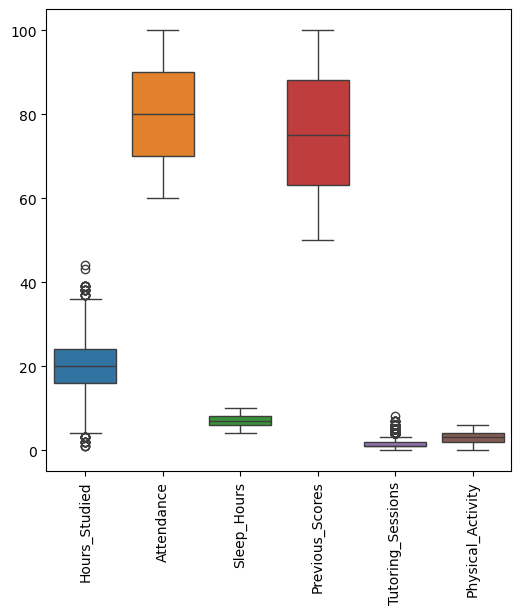

In [8]:

# ============================================================
# STEP 4 : Check Outliers
# ============================================================

plt.figure(figsize=(6,6))
sns.boxplot(data=X[num_cols])
plt.xticks(rotation=90)
plt.show()

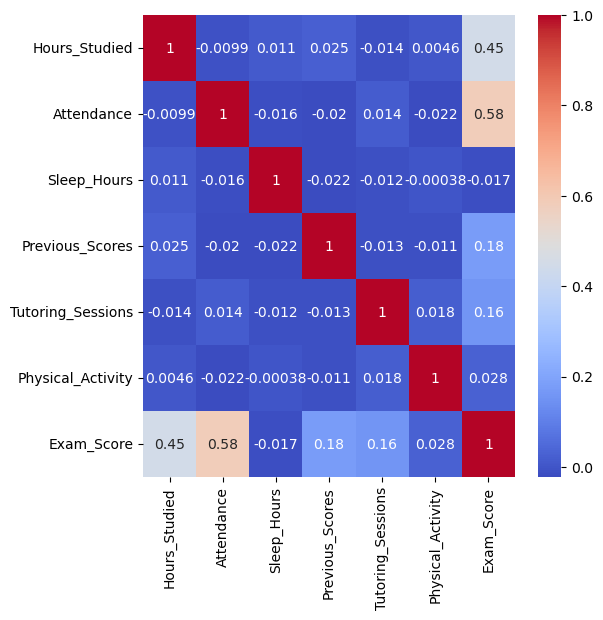

In [9]:

# ============================================================
# STEP 5 : Correlation Matrix
# ============================================================

plt.figure(figsize=(6,6))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm"
)
plt.show()

In [15]:
# ============================================================
# STEP 6 : Train Test Split
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    train_size=0.80,
    random_state=42

)

# ============================================================
# STEP 7 : Scaling Numerical Columns
# ============================================================

scaler = MinMaxScaler()
X_train[num_cols] = scaler.fit_transform(
    X_train[num_cols]
)

X_test[num_cols] = scaler.transform(

    X_test[num_cols]

)


In [11]:
# ============================================================
# STEP 8 : One Hot Encoding
# ============================================================

encoder = OneHotEncoder(sparse_output=False, handle_unknown="ignore")

# ------------------------------------------------------------
# Learn encoding from training data
# ------------------------------------------------------------

encoded_train = encoder.fit_transform(X_train[obj_cols])

# ------------------------------------------------------------
# Learn same mapping for test data
# ------------------------------------------------------------

encoded_test = encoder.transform(X_test[obj_cols])

# ============================================================
# STEP 9 : Get Newly Created Column Names
# ============================================================

encoded_columns = encoder.get_feature_names_out(obj_cols)
encoded_columns

array(['Parental_Involvement_High', 'Parental_Involvement_Low',
       'Parental_Involvement_Medium', 'Access_to_Resources_High',
       'Access_to_Resources_Low', 'Access_to_Resources_Medium',
       'Extracurricular_Activities_No', 'Extracurricular_Activities_Yes',
       'Motivation_Level_High', 'Motivation_Level_Low',
       'Motivation_Level_Medium', 'Internet_Access_No',
       'Internet_Access_Yes', 'Family_Income_High', 'Family_Income_Low',
       'Family_Income_Medium', 'Teacher_Quality_High',
       'Teacher_Quality_Low', 'Teacher_Quality_Medium',
       'Teacher_Quality_nan', 'School_Type_Private', 'School_Type_Public',
       'Peer_Influence_Negative', 'Peer_Influence_Neutral',
       'Peer_Influence_Positive', 'Learning_Disabilities_No',
       'Learning_Disabilities_Yes', 'Parental_Education_Level_College',
       'Parental_Education_Level_High School',
       'Parental_Education_Level_Postgraduate',
       'Parental_Education_Level_nan', 'Distance_from_Home_Far',
       

In [12]:

# ============================================================
# STEP 10 : Convert Encoded Arrays into DataFrames
# ============================================================

encoded_train = pd.DataFrame(
    encoded_train,
    columns=encoded_columns,
    index=X_train.index
)

encoded_test = pd.DataFrame(
    encoded_test,
    columns=encoded_columns,
    index=X_test.index
)

# ============================================================
# STEP 11 : Remove Original Categorical Columns
# ============================================================

X_train.drop(
    columns=obj_cols,
    inplace=True

)

X_test.drop(
    columns=obj_cols,
    inplace=True

)

In [13]:


# ============================================================
# STEP 12 : Add Encoded Columns
# ============================================================

X_train = pd.concat(
    [X_train, encoded_train],
    axis=1

)

X_test = pd.concat(
    [X_test, encoded_test],
    axis=1

)

# ============================================================
# Final Training Data
# ============================================================

print(X_train.head())
print()
print(X_train.shape)

# ============================================================
# STEP 13 : Train Model
# ============================================================

model = LinearRegression()

model.fit(
    X_train,
    y_train
)



      Hours_Studied  Attendance  Sleep_Hours  Previous_Scores  \
5810       0.619048       0.475     0.666667             0.26   
1268       0.357143       0.650     0.500000             0.88   
414        0.500000       0.675     0.666667             0.66   
4745       0.404762       1.000     1.000000             0.72   
654        0.809524       0.450     1.000000             0.98   

      Tutoring_Sessions  Physical_Activity  Parental_Involvement_High  \
5810              0.250           0.833333                        0.0   
1268              0.250           0.500000                        1.0   
414               0.125           0.166667                        0.0   
4745              0.125           0.500000                        1.0   
654               0.125           0.333333                        1.0   

      Parental_Involvement_Low  Parental_Involvement_Medium  \
5810                       1.0                          0.0   
1268                       0.0              

LinearRegression()

In [14]:
# ============================================================
# STEP 14 : Model Accuracy
# ============================================================

train_score = model.score(

    X_train,

    y_train

)

test_score = model.score(

    X_test,

    y_test

)

print("Train R² :", train_score)

print("Test  R² :", test_score)

# ============================================================
# STEP 15 : Conclusion
# ============================================================

difference = train_score - test_score

if difference < 0.05:

    print("Good Fit")

elif train_score > test_score:

    print("Overfitting")

else:

    print("Underfitting")

Train R² : 0.7174533445509724
Test  R² : 0.7699282240123634
Good Fit
